In [1]:
print("hello")

hello


In [2]:
from langgraph.graph import StateGraph, END, START
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model

import os
from dotenv import load_dotenv
load_dotenv(".env")

# from src.Agent.tools import (extend_query, parse_document_ocr, check_query_answerable, extract_issues, 
#                     search_rag, check_enough_context, generate_search_queries, search_web, 
#                     rerank_contexts, generate_answer, confirm_answer, retry_answer)
# from src.Agent.schemas import (UserInput, InputDocument, DocumentIssue, IssuesList, 
#                     CombinedQuery, QueryList, RAGOutput, RAGList, 
#                     EnoughContext, WebSearchQueries, WebSearchOutput, WebSearchList, 
#                     ContextOutput, ContextList, AnswerOutput, AnswerEnough)
from src.Agent.states import LegalAgentState
from src.Agent.functions import (load_prompt, route_by_input_type, document_ocr, filter_low_relevance_contexts,
                    route_by_enough_context, route_by_enough_answer, should_regenerate, route_after_document_parsing)
from src.Agent.nodes import (routing_node, query_rewriting_node, 
                            document_parsing_node, issue_extracting_node, 
                            rag_searching_node, context_evaluating_node, web_searching_node, 
                            context_reranking_node, context_filtering_node, answer_generating_node, answer_evaluating_node, answer_regenerating_node)

c:\Users\SAMSUNG\Desktop\Grad_School\RAG_LAW\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def legal_agent():
    """Legal Agent 그래프"""
    workflow = StateGraph(LegalAgentState)

    # 노드 추가
    workflow.add_node("input_router", routing_node)
    workflow.add_node("query_rewriter", query_rewriting_node)
    workflow.add_node("document_parser", document_parsing_node)
    workflow.add_node("issue_extractor", issue_extracting_node)
    workflow.add_node("rag_searcher", rag_searching_node)
    workflow.add_node("context_evaluator", context_evaluating_node)
    workflow.add_node("web_searcher", web_searching_node)
    workflow.add_node("context_reranker", context_reranking_node)
    workflow.add_node("context_filter", context_filtering_node)
    workflow.add_node("answer_generator", answer_generating_node)
    workflow.add_node("answer_evaluator", answer_evaluating_node)
    workflow.add_node("answer_regenerator", answer_regenerating_node)

    # 엣지 추가
    workflow.add_edge(START, "input_router")
    workflow.add_edge("input_router", "query_rewriter")
    workflow.add_conditional_edges(
        "query_rewriter", 
        route_by_input_type,
        {
            "Query_Only" : "rag_searcher", 
            "Hybrid" : "document_parser",
            "Error" : END
        }
    )
    workflow.add_conditional_edges(
        "document_parser",
        route_after_document_parsing,
        {
            "Hybrid" : "issue_extractor",
            "Query_Only" : "rag_searcher",
            "Error" : END
        }
    )
    workflow.add_edge("issue_extractor", "rag_searcher")
    workflow.add_edge("rag_searcher", "context_evaluator")
    workflow.add_conditional_edges(
        "context_evaluator",
        route_by_enough_context,
        {
            "ENOUGH" : "answer_generator",
            "NOT_ENOUGH" : "web_searcher"
        }
    )
    workflow.add_edge("web_searcher", "context_filter")
    workflow.add_edge("context_filter", "context_reranker")
    workflow.add_edge("context_reranker", "context_evaluator")
    workflow.add_edge("answer_generator", "answer_evaluator")
    workflow.add_conditional_edges(
        "answer_evaluator",
        route_by_enough_answer,
        {
            "ENOUGH" : END,
            "NOT_ENOUGH" : "answer_regenerator"
        }
    )
    workflow.add_conditional_edges(
        "answer_regenerator",
        should_regenerate,
        {
            "YES" : "answer_evaluator",
            "NO" : END
        }
    )

    return workflow.compile()

✅ 워크플로우 다이어그램이 'legal_agent_workflow.png'로 저장되었습니다!


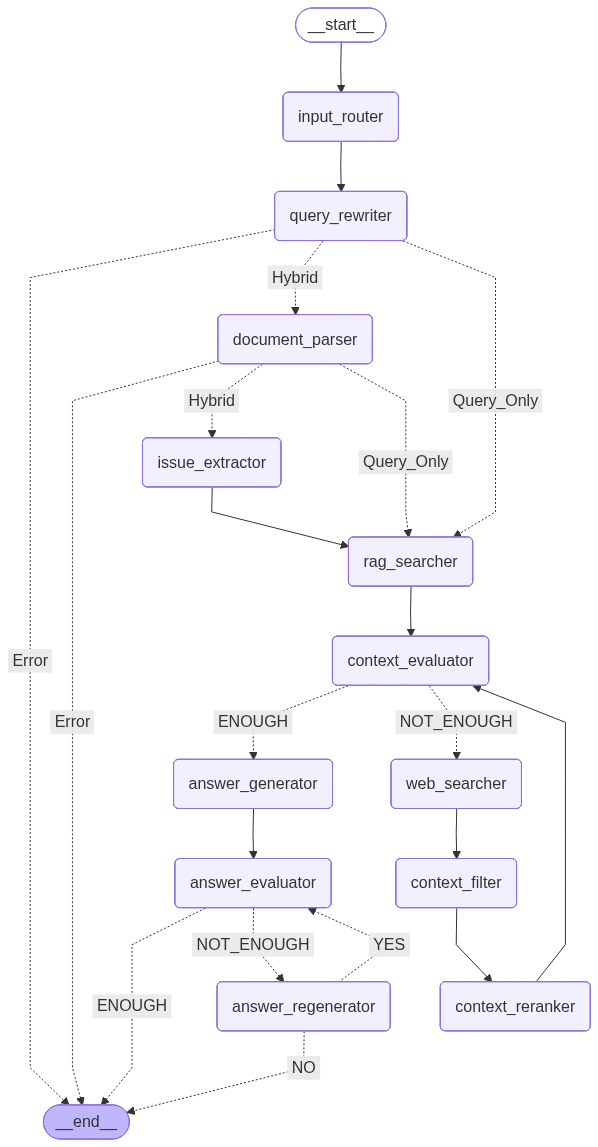

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02V\x00\x00\x04{\x08\x02\x00\x00\x00\xcd%}\x9a\x00\x00\x10\x00IDATx\x9c\xec\xdd\x05|\x13w\x1b\x07\xf0\xff\xa5\n-\xb4\x14\xd7Bq\x1b.c\x0c\xb7\xe1\xee\xb6\xe16`\xb8\xbb\xeb\x186\x06\xbc\xf8\xf0!\x1b\xee\xee\xee\xeeN\xa1FK\xdb$\xef\xaf9\x08\xa1F\x93&\x8d\xfd\xbe\xe3\xd3]\xce\xd3\xde\xdds\xff\xe79qT\xab\xd5\x82\x88\x88\xc8\xfe8\n"""\xbb\xc4\x10HDDv\x8a!\x90\x88\x88\xec\x14C \x11\x11\xd9)\x86@""\xb2S\x0c\x81DDd\xa7\x18\x02\x89,\xd7\xb9}\xfeO\xef\x05\x05\xfb+\xc3\xc3Ua\xc1\xdf\xbe\x7fIR\x085\xfeSI:\xbd\x84\x882\x9d\xe4 "n\x86RE\xe9\xa9\x8c:G\xcd\xe4Qf\x12\xfd\xc8B(\x9c%\x85$\\\x129$K\xed\x94\xaf\x84g\xea,\xce\x82\xc8\x82I\xbc/\x90\xc8\xd2\xecX\xf2\xea\xc9\x9d\xa0\x8f\xc1*G\'\xc9\xc5\xd5\xc1\xd1YBGh\x88\xf2\x9b\x13J\x0eR\xc4\xfe\xac\xfc\xb2SKR4\xfbx\xc4h*u\xe4\xa8\xa6\xd0\xf4\x8c4&&\x97\xc7SG\x99\x832\x9aC\x87\x93\x8bCD\xb4\x0eQ\x7f\x0cQ*\x95j\x84\xced)\x9d\x8bWM\x9e\xad\x90\x9b \xb2<\x0c\x81D\x16\xe4\x9f9\xcf^<\x08vI\xec\xe0\x9d+q\xf9F\xa9\x14V\

In [6]:
def save_agent_diagram():
    """에이전트 워크플로우를 PNG 이미지로 저장"""
    
    agent = legal_agent()
    
    try:
        # PNG 이미지로 저장
        from IPython.display import Image, display
        
        # 이미지 생성 및 저장
        img_data = agent.get_graph().draw_mermaid_png()
        
        # 파일로 저장
        with open("legal_agent_workflow.png", "wb") as f:
            f.write(img_data)
        
        print("✅ 워크플로우 다이어그램이 'legal_agent_workflow.png'로 저장되었습니다!")
        
        # Jupyter에서 이미지 표시
        display(Image(img_data))
        
        return img_data
        
    except ImportError:
        print("❌ 이미지 생성을 위해 추가 패키지가 필요합니다:")
        print("pip install pygraphviz")
        return None
    except Exception as e:
        print(f"❌ 이미지 저장 오류: {str(e)}")
        return None

# 이미지 저장
save_agent_diagram()